# Propane Market Intelligence — RAG + Forecasting Hybrid

**Author:** Sharma Tadepalli | **Purpose:** Hands-on RAG implementation (personal project, extends Azure GenAI coursework)

## Architecture

```
                    ┌─────────────────────────────┐
                    │  Document Corpus            │
                    │  EIA reports, NOAA outlooks,│
                    │  market commentary (.txt)   │
                    └──────────┬──────────────────┘
                               │ 1. Chunk (word windows + overlap)
                               ▼
                    ┌─────────────────────────────┐
                    │  Embeddings                 │
                    │  sentence-transformers      │
                    │  (all-MiniLM-L6-v2, local)  │
                    └──────────┬──────────────────┘
                               │ 2. Index
                               ▼
                    ┌─────────────────────────────┐
   User question ──▶│  Vector Store (ChromaDB)    │
                    │  top-k semantic retrieval   │
                    └──────────┬──────────────────┘
                               │ 3. Retrieved chunks + question
                               ▼
                    ┌─────────────────────────────┐
                    │  LLM (Claude API)           │
                    │  grounded answer + citations│
                    └─────────────────────────────┘

   Companion: classical time-series baseline on EIA weekly
   propane spot prices → forecast says WHAT, RAG explains WHY.
```

## Design decisions (interview talking points)

| Decision | Choice | Why |
|---|---|---|
| Embeddings | `all-MiniLM-L6-v2` (local, free) | Fast, no API cost, strong baseline; would benchmark vs. `text-embedding-3-small` / Azure embeddings in production |
| Vector store | ChromaDB (in-memory) | Zero-ops for prototype; production → Azure AI Search, pgvector, or Pinecone |
| Chunking | ~250 words, 50-word overlap | Report paragraphs are self-contained; overlap prevents boundary loss. Would test semantic chunking in production |
| Generation | Claude (Anthropic API) | Strong grounding behavior; swap-in cell provided for Azure OpenAI |
| Grounding | Strict system prompt + inline `[doc_id]` citations + "say so if not in context" | Primary hallucination control |
| Evaluation | Retrieval hit-rate + groundedness spot-check | Small gold QA set; production → RAGAS-style metrics, human eval |


## 0. Setup

Run in Google Colab. You need an **Anthropic API key** (console.anthropic.com) stored in Colab secrets as `ANTHROPIC_API_KEY` (key icon in left sidebar), or paste when prompted.

In [1]:
%pip -q install anthropic chromadb sentence-transformers pandas matplotlib scikit-learn

import os, glob, textwrap, json
import pandas as pd
import numpy as np

# --- API key: Colab secrets first, manual fallback ---
try:
    from google.colab import userdata
    os.environ["ANTHROPIC_API_KEY"] = userdata.get("ANTHROPIC_API_KEY")
except Exception:
    if "ANTHROPIC_API_KEY" not in os.environ:
        from getpass import getpass
        os.environ["ANTHROPIC_API_KEY"] = getpass("Anthropic API key: ")

from anthropic import Anthropic
client = Anthropic()
MODEL = "claude-sonnet-4-6"   # cost-effective, strong grounding
print("Setup complete.")

## 1. Build the corpus

**Real corpus (do this before Wednesday):** create a folder `corpus/` and save 20–40 short `.txt` files from public sources. Good sources:

- **EIA — This Week in Petroleum** (weekly, has propane/NGL commentary): eia.gov/petroleum/weekly
- **EIA — Heating Oil and Propane Update** (winter season): eia.gov/petroleum/heatingoilpropane
- **EIA — Short-Term Energy Outlook (STEO)**, propane/NGL sections: eia.gov/outlooks/steo
- **NOAA CPC seasonal temperature outlooks** (text discussion): cpc.ncep.noaa.gov

Copy the *text* of each report/section into its own `.txt` file, named descriptively, e.g. `eia_twip_2025-01-15.txt`. Filename becomes the citation ID — put the date in it.

**Starter corpus:** the cell below writes 6 small synthetic sample documents (written for this notebook, modeled on the *style* of EIA/NOAA commentary — not real excerpts) so the whole pipeline runs end-to-end immediately. Replace with real documents once collected.

In [2]:
os.makedirs("corpus", exist_ok=True)

SAMPLE_DOCS = {
"sample_market_note_2025-01-20.txt": """Propane market note, week of January 20, 2025.
Mont Belvieu propane spot prices rose sharply this week as an Arctic air mass pushed
across the Midwest and Gulf Coast, lifting residential heating demand well above the
five-year average. Regional inventories drew down at the fastest weekly rate of the
season. Crop-drying demand had already tightened Midwest stocks in the fall, leaving
less buffer than usual entering the cold snap. Export terminals on the Gulf Coast
continued to run near capacity, with strong waterborne demand from Asian petrochemical
buyers competing directly with domestic heating demand for available barrels.""",

"sample_market_note_2025-02-10.txt": """Propane market note, week of February 10, 2025.
Spot prices at Mont Belvieu eased from January highs as temperatures moderated across
major heating regions. Inventory draws slowed to near-average rates. Fractionation
volumes from the Permian remained robust, and rising natural gas liquids supply began
to rebuild the stock cushion. Export arbitrage to Asia narrowed as freight rates
increased, modestly reducing loadings at Gulf Coast terminals.""",

"sample_seasonal_outlook_2024-11-01.txt": """Seasonal temperature outlook discussion,
issued November 2024, covering December through February. Forecast guidance indicates
elevated probabilities of below-normal temperatures across the north-central United
States, consistent with a weak La Nina pattern. The Gulf Coast and Southeast lean
toward near-normal temperatures. Heating degree day accumulations in the Midwest are
projected modestly above the ten-year normal, implying above-average residential
propane heating demand in that region.""",

"sample_supply_note_2024-12-05.txt": """Supply commentary, December 2024. U.S. propane
production continued to set records, driven by natural gas liquids growth from the
Permian Basin and expanded fractionation capacity on the Gulf Coast. Propane exports
also reached record levels, supported by new export terminal capacity. The U.S. market
has become structurally export-linked: domestic prices increasingly reflect global
demand, particularly Asian petrochemical (PDH plant) demand, rather than domestic
heating demand alone.""",

"sample_inventory_note_2024-10-15.txt": """Inventory note, October 2024. U.S. propane
inventories entered the heating season near the top of the five-year range in the Gulf
Coast region, though Midwest stocks were below average following a large, late corn
harvest that raised crop-drying demand. Analysts noted that regional imbalances, rather
than the national total, tend to drive localized price spikes during severe cold events
because pipeline and rail logistics limit how quickly barrels can be repositioned.""",

"sample_price_history_note_2025-03-01.txt": """Season recap, March 2025. Mont Belvieu
propane averaged materially higher this heating season than last, with the January cold
event producing the season's peak. Key drivers in order of impact: (1) the January
Arctic outbreak and associated heating degree day spike, (2) record export volumes
competing for supply, (3) below-average Midwest inventories entering the season.
Weather remained the dominant short-term driver, while exports set the structural
price floor.""",
}

for name, text in SAMPLE_DOCS.items():
    with open(f"corpus/{name}", "w") as f:
        f.write(text)

paths = sorted(glob.glob("corpus/*.txt"))
print(f"{len(paths)} documents in corpus:")
for p in paths: print(" -", p)

6 documents in corpus:
 - corpus/sample_inventory_note_2024-10-15.txt
 - corpus/sample_market_note_2025-01-20.txt
 - corpus/sample_market_note_2025-02-10.txt
 - corpus/sample_price_history_note_2025-03-01.txt
 - corpus/sample_seasonal_outlook_2024-11-01.txt
 - corpus/sample_supply_note_2024-12-05.txt


## 2. Chunking

Simple word-window chunker: ~250 words per chunk, 50-word overlap.

**Interview point:** chunk size trades off retrieval *precision* (small chunks match queries tightly) against *context completeness* (large chunks give the LLM enough to reason with). Overlap prevents losing facts that straddle a boundary. Production alternatives: semantic chunking, heading-aware splitting, parent-document retrieval (retrieve small, feed large).

In [3]:
def chunk_text(text, chunk_words=250, overlap=50):
    words = text.split()
    if len(words) <= chunk_words:
        return [text.strip()]
    chunks, start = [], 0
    while start < len(words):
        chunks.append(" ".join(words[start:start + chunk_words]))
        start += chunk_words - overlap
    return chunks

records = []   # {id, doc_id, text}
for path in sorted(glob.glob("corpus/*.txt")):
    doc_id = os.path.basename(path).replace(".txt", "")
    with open(path) as f:
        raw = f.read()
    for i, ch in enumerate(chunk_text(raw)):
        records.append({"id": f"{doc_id}::chunk{i}", "doc_id": doc_id, "text": ch})

print(f"{len(records)} chunks from {len(set(r['doc_id'] for r in records))} documents")
print("\nExample chunk:\n", textwrap.fill(records[0]["text"][:400], 100))

6 chunks from 6 documents

Example chunk:
 Inventory note, October 2024. U.S. propane inventories entered the heating season near the top of
the five-year range in the Gulf Coast region, though Midwest stocks were below average following a
large, late corn harvest that raised crop-drying demand. Analysts noted that regional imbalances,
rather than the national total, tend to drive localized price spikes during severe cold events
because pi


## 3. Embed and index (ChromaDB + sentence-transformers)

Local embeddings: free, fast, no rate limits — right call for a prototype. In production I would benchmark against a hosted embedding model on a retrieval eval set before choosing.

In [4]:
from sentence_transformers import SentenceTransformer
import chromadb

embedder = SentenceTransformer("all-MiniLM-L6-v2")   # 384-dim

chroma = chromadb.Client()
try: chroma.delete_collection("propane")
except Exception: pass
collection = chroma.create_collection("propane", metadata={"hnsw:space": "cosine"})

texts = [r["text"] for r in records]
embs = embedder.encode(texts, show_progress_bar=True, normalize_embeddings=True)

collection.add(
    ids=[r["id"] for r in records],
    embeddings=embs.tolist(),
    documents=texts,
    metadatas=[{"doc_id": r["doc_id"]} for r in records],
)
print(f"Indexed {collection.count()} chunks.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Indexed 6 chunks.


### Sanity-check retrieval (before touching the LLM)

Always debug retrieval in isolation — most RAG failures are retrieval failures, not generation failures. **Interview point:** this is the "look at your data" discipline, same as inspecting seismic gathers before inverting them.

In [5]:
def retrieve(query, k=4):
    q_emb = embedder.encode([query], normalize_embeddings=True)
    res = collection.query(query_embeddings=q_emb.tolist(), n_results=k)
    return [
        {"id": i, "doc_id": m["doc_id"], "text": d, "distance": dist}
        for i, m, d, dist in zip(res["ids"][0], res["metadatas"][0],
                                 res["documents"][0], res["distances"][0])
    ]

for hit in retrieve("Why did propane prices spike in January?"):
    print(f"[{hit['distance']:.3f}] {hit['id']}")
    print("   ", textwrap.shorten(hit["text"], 140), "\n")

[0.303] sample_market_note_2025-01-20::chunk0
    Propane market note, week of January 20, 2025. Mont Belvieu propane spot prices rose sharply this week as an Arctic air mass pushed [...] 

[0.317] sample_market_note_2025-02-10::chunk0
    Propane market note, week of February 10, 2025. Spot prices at Mont Belvieu eased from January highs as temperatures moderated across [...] 

[0.320] sample_inventory_note_2024-10-15::chunk0
    Inventory note, October 2024. U.S. propane inventories entered the heating season near the top of the five-year range in the Gulf [...] 

[0.336] sample_price_history_note_2025-03-01::chunk0
    Season recap, March 2025. Mont Belvieu propane averaged materially higher this heating season than last, with the January cold event [...] 



## 4. Grounded generation with Claude

The system prompt enforces grounding: answer **only** from retrieved context, cite `[doc_id]` inline, and explicitly say when the context doesn't contain the answer. That last instruction is the single most effective hallucination control in a RAG system.

In [6]:
SYSTEM_PROMPT = """You are a propane market analyst assistant. Answer the user's
question using ONLY the context documents provided. Rules:
1. Cite sources inline using the doc_id in square brackets, e.g. [sample_market_note_2025-01-20].
2. If the context does not contain the information needed, say exactly that and do not
   speculate. Suggest what kind of document would answer it.
3. Be concise and quantitative where the context allows.
4. Do not use outside knowledge about prices or events."""

def rag_answer(question, k=4, show_context=False):
    hits = retrieve(question, k=k)
    context = "\n\n".join(f"<doc id='{h['doc_id']}'>\n{h['text']}\n</doc>" for h in hits)
    if show_context:
        print("--- retrieved ---")
        for h in hits: print(" ", h["id"], f"(dist {h['distance']:.3f})")
        print("-----------------\n")
    msg = client.messages.create(
        model=MODEL, max_tokens=700, system=SYSTEM_PROMPT,
        messages=[{"role": "user",
                   "content": f"Context documents:\n{context}\n\nQuestion: {question}"}],
    )
    return msg.content[0].text

print(rag_answer("Why did Mont Belvieu propane prices spike in January 2025?", show_context=True))

--- retrieved ---
  sample_market_note_2025-02-10::chunk0 (dist 0.209)
  sample_market_note_2025-01-20::chunk0 (dist 0.217)
  sample_price_history_note_2025-03-01::chunk0 (dist 0.280)
  sample_inventory_note_2024-10-15::chunk0 (dist 0.399)
-----------------

Based on the context documents, Mont Belvieu propane prices spiked in January 2025 due to several concurrent factors:

1. **Arctic weather event**: An Arctic air mass pushed across the Midwest and Gulf Coast, driving residential heating demand well above the five-year average and causing the fastest weekly inventory draw of the season [sample_market_note_2025-01-20].

2. **Below-average Midwest inventories entering the season**: Crop-drying demand from a large, late corn harvest had already tightened Midwest stocks in the fall [sample_inventory_note_2024-10-15], leaving less buffer than usual when the cold snap hit [sample_market_note_2025-01-20].

3. **Competition from record export volumes**: Gulf Coast export terminals were runn

In [7]:
# More probes — including one designed to trigger the "not in context" behavior.
for q in [
    "What role do exports play in U.S. propane prices?",
    "How did Midwest inventories look entering the 2024-25 heating season, and why?",
    "What was the price of WTI crude oil in January 2025?",   # NOT in corpus -> should decline
]:
    print("Q:", q)
    print(rag_answer(q))
    print("=" * 90)

Q: What role do exports play in U.S. propane prices?
Based on the context documents, exports play a significant and structural role in U.S. propane pricing through several mechanisms:

1. **Structural price linkage to global markets**: The U.S. market has become "structurally export-linked," meaning domestic prices increasingly reflect **global demand** — particularly from Asian petrochemical (PDH plant) buyers — rather than domestic heating demand alone [sample_supply_note_2024-12-05].

2. **Direct competition with domestic demand**: Export terminals on the Gulf Coast run near capacity, creating direct competition between waterborne demand from Asian petrochemical buyers and domestic heating demand for available barrels. This competition contributes to price spikes during periods of high domestic demand [sample_market_note_2025-01-20].

3. **Dampening effect when arbitrage narrows**: Conversely, when the export arbitrage to Asia narrows (e.g., due to rising freight rates), Gulf Coast 

### Optional: swap in your Azure OpenAI deployment

To frame this as extending your Azure GenAI project, replace the generation call with your Azure deployment (endpoint, deployment name, and key from your existing project):

```python
# %pip -q install openai
from openai import AzureOpenAI
azure = AzureOpenAI(azure_endpoint="https://<your-resource>.openai.azure.com",
                    api_key=AZURE_KEY, api_version="2024-08-01-preview")
resp = azure.chat.completions.create(
    model="<your-gpt-deployment-name>",
    messages=[{"role": "system", "content": SYSTEM_PROMPT},
              {"role": "user", "content": f"Context:\n{context}\n\nQuestion: {question}"}])
answer = resp.choices[0].message.content
```

**Interview point:** the RAG architecture is model-agnostic — retrieval layer unchanged, generation layer swappable. You have hands-on with both Anthropic and Azure OpenAI stacks.

## 5. Evaluation

Two lightweight metrics on a small gold QA set:

1. **Retrieval hit-rate@k** — is the document that contains the answer in the top-k retrieved? (Retrieval quality, no LLM involved.)
2. **Groundedness spot-check** — LLM-as-judge: is every claim in the answer supported by the retrieved context?

**Interview point:** in production I'd expand to RAGAS-style metrics (faithfulness, answer relevance, context precision/recall), a larger curated eval set, and periodic human review. Evaluation is the part most RAG teams under-invest in — and it's where my background in validating probabilistic models against drilling outcomes maps directly.

In [8]:
GOLD_QA = [
    {"q": "Why did propane prices spike in January 2025?",
     "expected_doc": "sample_market_note_2025-01-20"},
    {"q": "What was the winter temperature outlook for the Midwest?",
     "expected_doc": "sample_seasonal_outlook_2024-11-01"},
    {"q": "Why were Midwest propane inventories below average in fall 2024?",
     "expected_doc": "sample_inventory_note_2024-10-15"},
    {"q": "How do exports affect U.S. propane prices structurally?",
     "expected_doc": "sample_supply_note_2024-12-05"},
]

K = 4
hits = 0
for item in GOLD_QA:
    retrieved_docs = {h["doc_id"] for h in retrieve(item["q"], k=K)}
    ok = item["expected_doc"] in retrieved_docs
    hits += ok
    print(("HIT " if ok else "MISS"), "|", item["q"])
print(f"\nRetrieval hit-rate@{K}: {hits}/{len(GOLD_QA)} = {hits/len(GOLD_QA):.0%}")

HIT  | Why did propane prices spike in January 2025?
HIT  | What was the winter temperature outlook for the Midwest?
HIT  | Why were Midwest propane inventories below average in fall 2024?
HIT  | How do exports affect U.S. propane prices structurally?

Retrieval hit-rate@4: 4/4 = 100%


In [9]:
JUDGE_PROMPT = """You are evaluating a RAG system. Given the context documents and an
answer, classify the answer as GROUNDED (every factual claim is supported by the
context) or UNGROUNDED (contains claims not supported by the context). Reply with one
word, then one sentence of justification."""

def groundedness_check(question, k=4):
    hits = retrieve(question, k=k)
    context = "\n\n".join(f"<doc id='{h['doc_id']}'>\n{h['text']}\n</doc>" for h in hits)
    answer = rag_answer(question, k=k)
    verdict = client.messages.create(
        model=MODEL, max_tokens=150, system=JUDGE_PROMPT,
        messages=[{"role": "user",
                   "content": f"Context:\n{context}\n\nAnswer to evaluate:\n{answer}"}],
    ).content[0].text
    print("Q:", question, "\nA:", answer, "\nJudge:", verdict)

groundedness_check("Why did propane prices spike in January 2025?")

Q: Why did propane prices spike in January 2025? 
A: Based on the context documents, propane prices spiked in January 2025 due to several converging factors:

1. **Extreme cold weather**: An Arctic air mass pushed across the Midwest and Gulf Coast, driving residential heating demand well above the five-year average [sample_market_note_2025-01-20].

2. **Depleted Midwest inventory buffer**: Crop-drying demand from a large, late corn harvest had already drawn down Midwest stocks below average entering the heating season, leaving less cushion than usual when the cold snap hit [sample_inventory_note_2024-10-15, sample_market_note_2025-01-20].

3. **Record inventory draws**: Regional inventories drew down at the fastest weekly rate of the season [sample_market_note_2025-01-20].

4. **Export competition**: Gulf Coast export terminals continued running near capacity, with strong Asian petrochemical (PDH plant) buyers competing directly with domestic heating demand for available barrels [sampl

## 6. Companion: classical price forecast (optional but powerful)

RAG retrieves and explains; it does **not** forecast. Forecasting is a classical
time-series problem — so we do it classically, then let the two systems complement
each other: *the model says what, the RAG system explains why.*

**Data (5 minutes to get):** EIA publishes weekly Mont Belvieu propane spot prices.
Go to eia.gov → search "Mont Belvieu propane spot price" (series `EER_EPLLPA_PF4_Y44MB_DPG`),
download ~3 years of weekly data as CSV, upload to Colab as `propane_weekly.csv` with
columns `date, price`. The cell below generates a synthetic stand-in (seasonal + trend +
noise) so the pipeline runs immediately; swap in the real file when you have it.

Using synthetic stand-in data (replace with EIA CSV).
MAE  linear model : 0.0079 $/gal
MAE  naive (t-1)  : 0.0156 $/gal


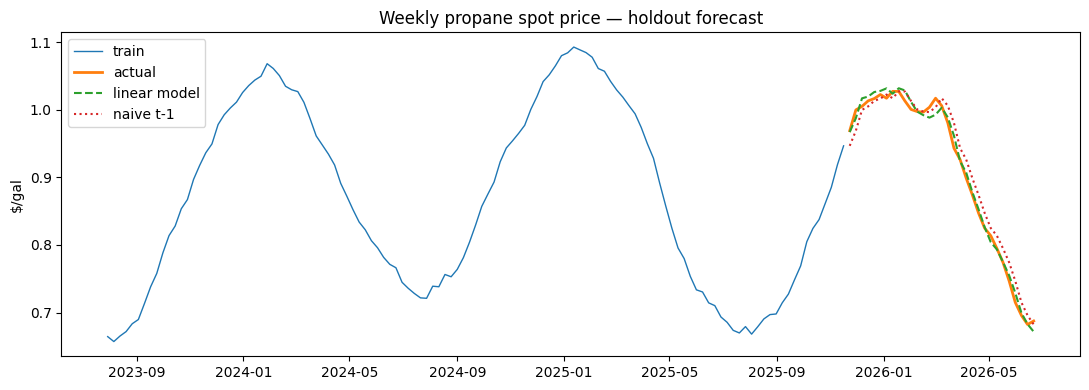

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# --- Load real data if present, else synthesize a plausible weekly series ---
if os.path.exists("propane_weekly.csv"):
    df = pd.read_csv("propane_weekly.csv", parse_dates=["date"]).sort_values("date")
    print("Loaded real EIA data.")
else:
    rng = np.random.default_rng(42)
    dates = pd.date_range("2023-07-01", periods=156, freq="W")   # ~3 years
    week_of_year = dates.isocalendar().week.to_numpy().astype(float)
    seasonal = 0.18 * np.cos(2 * np.pi * (week_of_year - 3) / 52)   # winter peak
    trend = np.linspace(0, 0.08, len(dates))
    noise = rng.normal(0, 0.03, len(dates)).cumsum() * 0.3
    df = pd.DataFrame({"date": dates, "price": 0.85 + seasonal + trend + noise})
    print("Using synthetic stand-in data (replace with EIA CSV).")

# --- Features: lags + heating-season proxy (cyclical week-of-year encoding) ---
df = df.reset_index(drop=True)
for lag in (1, 2, 4):
    df[f"lag{lag}"] = df["price"].shift(lag)
woy = pd.to_datetime(df["date"]).dt.isocalendar().week.astype(float)
df["woy_sin"] = np.sin(2 * np.pi * woy / 52)   # proxy for heating degree days;
df["woy_cos"] = np.cos(2 * np.pi * woy / 52)   # replace with NOAA HDD data if time allows
df = df.dropna().reset_index(drop=True)

features = ["lag1", "lag2", "lag4", "woy_sin", "woy_cos"]
split = int(len(df) * 0.8)                      # time-ordered split — never shuffle time series
train, test = df.iloc[:split], df.iloc[split:]

model = LinearRegression().fit(train[features], train["price"])
pred = model.predict(test[features])
naive = test["lag1"]                            # persistence baseline: next week = this week

print(f"MAE  linear model : {mean_absolute_error(test['price'], pred):.4f} $/gal")
print(f"MAE  naive (t-1)  : {mean_absolute_error(test['price'], naive):.4f} $/gal")

plt.figure(figsize=(11, 4))
plt.plot(train["date"], train["price"], label="train", lw=1)
plt.plot(test["date"], test["price"], label="actual", lw=2)
plt.plot(test["date"], pred, "--", label="linear model")
plt.plot(test["date"], naive, ":", label="naive t-1")
plt.legend(); plt.title("Weekly propane spot price — holdout forecast")
plt.ylabel("$/gal"); plt.tight_layout(); plt.show()

**Interview points for this section:**
- Always benchmark against a **naive persistence baseline** — commodity prices are near-random-walk at weekly frequency, and beating persistence is genuinely hard. Reporting the comparison honestly signals seniority.
- **Time-ordered split**, never a shuffled split — shuffling leaks the future into training. (Same leakage discipline as blind-well tests in seismic inversion.)
- Week-of-year encoding is a *proxy* for heating degree days; the upgrade path is actual NOAA HDD data and inventory levels as features.

In [11]:
# The hybrid demo: quant output + RAG explanation in one answer.
latest = df.iloc[-1]
direction = "up" if pred[-1] > test["price"].iloc[-2] else "down"
question = (f"The forecasting model projects propane prices moving {direction} in the "
            f"coming weeks. Based on the corpus, what fundamental drivers would explain "
            f"a move {direction} at this time of year, and what should an analyst watch?")
print(rag_answer(question))

## Fundamental Drivers for a Propane Price Decline

Based on the provided documents, several fundamental factors would support a downward price move:

### 1. Demand-Side Easing
- **Moderation in heating demand** is the most direct driver. When temperatures normalize after a cold snap, residential heating demand falls back toward or below seasonal averages, slowing inventory draws [sample_market_note_2025-02-10].
- Inventory draws reverting to **near-average rates** directly reduce the urgency premium built into spot prices [sample_market_note_2025-02-10].

### 2. Supply-Side Recovery
- **Robust Permian fractionation volumes** continuously add supply to the system. As demand eases, this production flow rebuilds the stock cushion relatively quickly [sample_market_note_2025-02-10].
- U.S. propane production has been at **record levels** driven by NGL growth from the Permian and expanded Gulf Coast fractionation capacity, meaning the supply response to any demand lull can be rapid [sample_

## 7. What I'd do next (production roadmap — say this in interviews)

1. **Corpus & ingestion:** automated pipeline pulling EIA/NOAA releases on schedule; document versioning; PDF parsing for STEO reports.
2. **Retrieval quality:** hybrid search (BM25 + dense), reranking (cross-encoder), metadata filtering by date so "this winter" retrieves the right season.
3. **Evaluation at scale:** RAGAS-style faithfulness/relevance metrics, curated eval set with SME review, regression testing on every corpus or prompt change.
4. **Agentic extension:** tool-use so the assistant can query the price database directly (structured) *and* the corpus (unstructured) — the pattern enterprise clients actually want.
5. **Deployment:** Azure AI Search as the vector store, managed identity for keys, monitoring for retrieval drift.

---

## One-paragraph project summary (memorize for Wednesday)

> "Last weekend I extended my Azure GenAI work into a full RAG implementation: a propane
> market intelligence assistant. I built a corpus of EIA and NOAA market commentary,
> chunked it with overlap, embedded with sentence-transformers into ChromaDB, and wired
> retrieval into Claude with a strict grounding prompt and inline citations. I evaluated
> it with retrieval hit-rate on a gold QA set and LLM-as-judge groundedness checks —
> including negative tests where the answer isn't in the corpus, to verify it declines
> rather than hallucinates. I paired it with a classical time-series baseline on EIA
> weekly spot prices, benchmarked against naive persistence, so the quant model says
> *what* and the RAG system explains *why*. Small scale, but I made every architecture
> decision deliberately and I know the production upgrade path for each component."
